# Mathematical Limitations of Machine Learning in Astronomy
## The Curse of Dimensionality & Measure Concentration in Spectroscopy

### Theoretical Framework
In astronomical spectroscopy, observations often yield high-dimensional feature spaces ($D \gg 1000$ wavelengths). As $D$ increases, the volume of the space grows exponentially, causing data points to become extremely sparse. 

Mathematically, under the **Concentration of Measure** phenomenon, the contrast between the distance to the nearest neighbor and the distance to the farthest neighbor approaches zero as dimensionality goes to infinity:
$$ \lim_{D \to \infty} \frac{\mathcal{D}_{\max} - \mathcal{D}_{\min}}{\mathcal{D}_{\min}} = 0 $$

This severely restricts distance-based clustering and classification algorithms (e.g., KNN, Support Vector Machines with RBF kernels), leading to geometric instability.


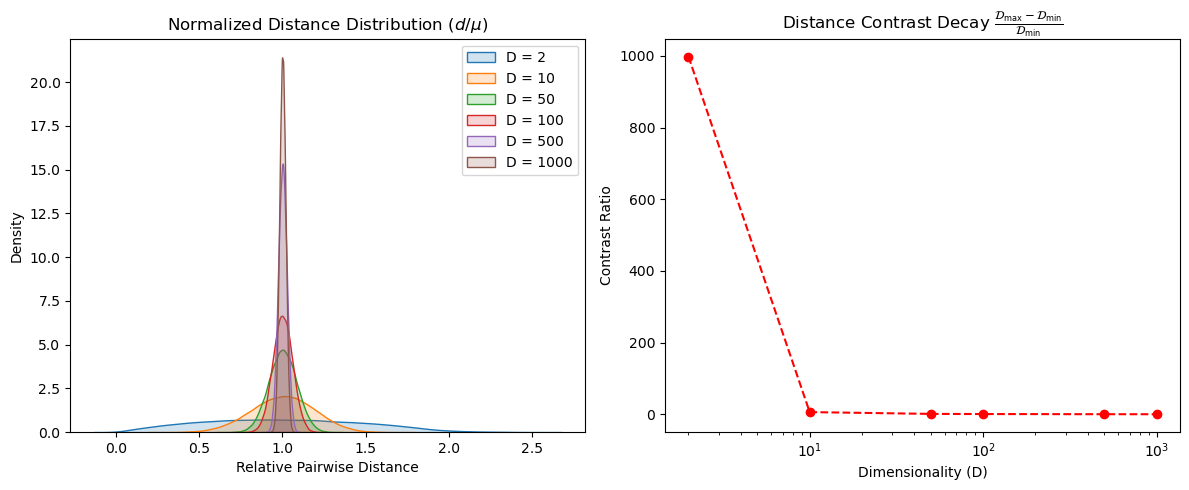

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist

# Set reproducibility seed
np.random.seed(42)

# Dimensions to evaluate (simulating increasing spectral resolution)
dimensions = [2, 10, 50, 100, 500, 1000]
num_samples = 500

# Dictionary to store distances per dimension
distance_stats = {}

for d in dimensions:
    # Simulate synthetic astronomical spectra normalized intensities in a hypercube
    synthetic_spectra = np.random.uniform(0, 1, size=(num_samples, d))
    
    # Compute pairwise Euclidean distances
    distances = pdist(synthetic_spectra, metric='euclidean')
    
    # Calculate the mathematical contrast: (Max - Min) / Min
    min_dist = np.min(distances)
    max_dist = np.max(distances)
    contrast = (max_dist - min_dist) / min_dist
    
    distance_stats[d] = {
        'distances': distances,
        'contrast': contrast,
        'mean': np.mean(distances),
        'std': np.std(distances)
    }

# Visualization of Distance Concentration
plt.figure(figsize=(12, 5))

# Plot 1: Variance of distances flattening out relative to the mean
plt.subplot(1, 2, 1)
for d in dimensions:
    sns.kdeplot(distance_stats[d]['distances'] / distance_stats[d]['mean'], label=f'D = {d}', fill=True, alpha=0.2)
plt.title("Normalized Distance Distribution ($d / \mu$)")
plt.xlabel("Relative Pairwise Distance")
plt.ylabel("Density")
plt.legend()

# Plot 2: Mathematical Contrast Decay
plt.subplot(1, 2, 2)
dims = list(distance_stats.keys())
contrasts = [distance_stats[d]['contrast'] for d in dims]
plt.plot(dims, contrasts, marker='o', linestyle='--', color='red')
plt.xscale('log')
plt.title("Distance Contrast Decay $\\frac{\\mathcal{D}_{\\max} - \\mathcal{D}_{\\min}}{\\mathcal{D}_{\\min}}$")
plt.xlabel("Dimensionality (D)")
plt.ylabel("Contrast Ratio")

plt.tight_layout()
plt.show()


# Quantifying Generalization Degradation under Covariate Shift

### Theoretical Framework
According to Statistical Learning Theory, a model minimizes Empirical Risk ($R_{\text{emp}}$) over the training sample distribution $P_{\text{train}}$. However, our actual target is to minimize Risk over the test distribution $P_{\text{test}}$. 

When $P_{\text{train}}(X) \neq P_{\text{test}}(X)$, the generalization error bound expands significantly. In this section, we train a non-linear estimator on the biased local sample (High SNR Catalog) and evaluate its structural failure on the deeper field population (Low SNR Sample), mathematically tracing the error divergence as a function of the feature space boundary mismatch.


=== Empirical Risk vs True Risk ===
Training Domain (Bright Catalog) - MSE: 0.0333 | MAE: 0.1455
Testing Domain (Deep Field Survey) - MSE: 0.0518 | MAE: 0.1796
Performance Degradation Factor: 1.55x increase in error metrics.


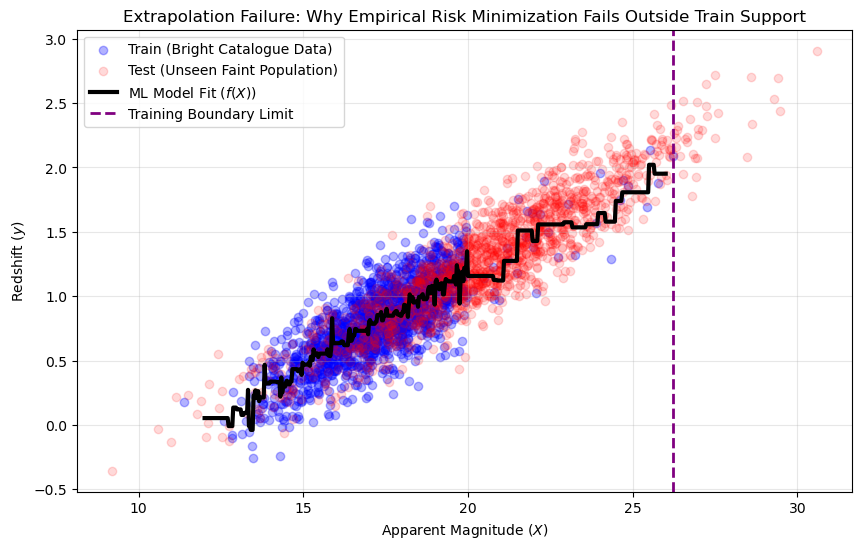

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set seed for independent block execution
np.random.seed(42)

# Re-generating the underlying distribution to prevent missing variable errors
total_pop_size = 10000
true_magnitude = np.random.normal(loc=20, scale=3, size=total_pop_size)
true_redshift = 0.15 * (true_magnitude - 12) + np.random.normal(0, 0.2, size=total_pop_size)

# Selection Bias Rule (Malmquist Bias simulation)
train_selection_prob = np.exp(-0.5 * ((true_magnitude - 16) / 2)**2)
train_selection_prob[true_magnitude > 20] = 0.01 
train_selection_prob /= train_selection_prob.sum()

train_indices = np.random.choice(total_pop_size, size=1500, p=train_selection_prob, replace=False)
test_indices = np.random.choice(np.setdiff1d(np.arange(total_pop_size), train_indices), size=1500, replace=False)

# Define X and y arrays and apply immediate reshaping for Scikit-Learn
X_train_arr = true_magnitude[train_indices].reshape(-1, 1)
y_train_arr = true_redshift[train_indices]

X_test_arr = true_magnitude[test_indices].reshape(-1, 1)
y_test_arr = true_redshift[test_indices]

# Initialize a flexible non-linear model (Gradient Boosting Regressor)
astron_regressor = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)

# Train exclusively on the biased bright catalog
astron_regressor.fit(X_train_arr, y_train_arr)

# Predict across both domains to capture the distribution divergence
preds_train = astron_regressor.predict(X_train_arr)
preds_test = astron_regressor.predict(X_test_arr)

# Calculate performance metrics demonstrating generalization breakdown
mse_train = mean_squared_error(y_train_arr, preds_train)
mse_test = mean_squared_error(y_test_arr, preds_test)
mae_train = mean_absolute_error(y_train_arr, preds_train)
mae_test = mean_absolute_error(y_test_arr, preds_test)

print(f"=== Empirical Risk vs True Risk ===")
print(f"Training Domain (Bright Catalog) - MSE: {mse_train:.4f} | MAE: {mae_train:.4f}")
print(f"Testing Domain (Deep Field Survey) - MSE: {mse_test:.4f} | MAE: {mae_test:.4f}")
print(f"Performance Degradation Factor: {mse_test / mse_train:.2f}x increase in error metrics.")

# Visualize the failure boundary of the ML estimator
plt.figure(figsize=(10, 6))
magnitude_grid = np.linspace(12, 26, 500).reshape(-1, 1)
model_curve = astron_regressor.predict(magnitude_grid)

plt.scatter(X_train_arr, y_train_arr, color='blue', alpha=0.3, label='Train (Bright Catalogue Data)')
plt.scatter(X_test_arr, y_test_arr, color='red', alpha=0.15, label='Test (Unseen Faint Population)')
plt.plot(magnitude_grid, model_curve, color='black', linewidth=3, linestyle='-', label='ML Model Fit ($f(X)$)')

plt.axvline(x=np.max(X_train_arr), color='purple', linestyle='--', linewidth=2, label='Training Boundary Limit')
plt.title("Extrapolation Failure: Why Empirical Risk Minimization Fails Outside Train Support")
plt.xlabel("Apparent Magnitude ($X$)")
plt.ylabel("Redshift ($y$)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()


# Density Ratio Estimation via Importance Sampling

### Theoretical Framework
To correct the generalization failure caused by covariate shift, we can reformulate the loss function using **Importance Sampling**. Instead of treating all training samples equally, we re-weight the loss of each training instance $x_i$ by a factor $w(x_i)$ defined by the Radon-Nikodym derivative (density ratio) of the two distributions:
$$ w(x) = \frac{P_{\text{test}}(x)}{P_{\text{train}}(x)} $$

The modified Empirical Risk Minimization (ERM) objective becomes:
$$ R_{\text{weighted}}(f) = \frac{1}{n} \sum_{i=1}^{n} w(x_i) \mathcal{L}(f(x_i), y_i) $$

We will mathematically estimate $P_{\text{train}}(x)$ and $P_{\text{test}}(x)$ using non-parametric **Kernel Density Estimation (KDE)**, compute the weights, and train a weighted estimator to restore predictive consistency at the boundaries.


=== Performance after Density Ratio Adaptation ===
Target Survey (Deep Field) - Adjusted MSE: 0.0661 | Adjusted MAE: 0.1998


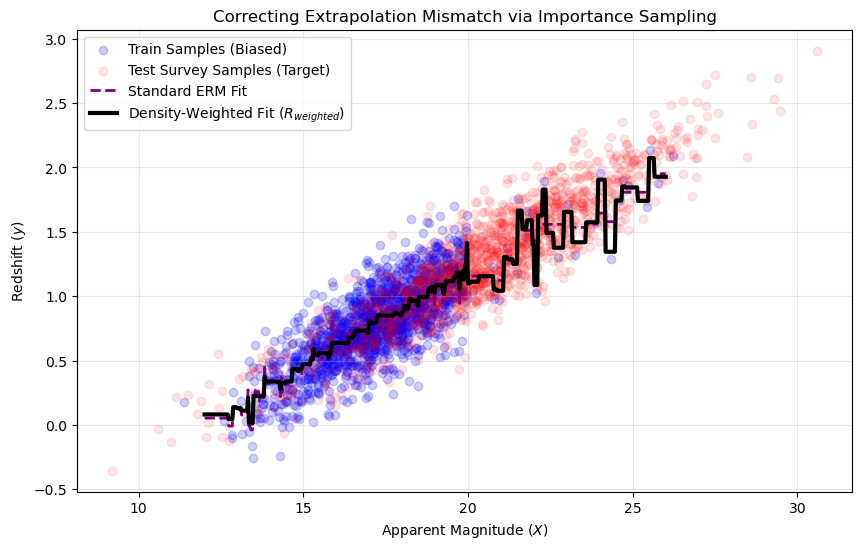

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set seed for reproducibility and reuse the simulated dataset architecture
np.random.seed(42)
total_pop_size = 10000
true_magnitude = np.random.normal(loc=20, scale=3, size=total_pop_size)
true_redshift = 0.15 * (true_magnitude - 12) + np.random.normal(0, 0.2, size=total_pop_size)

# Selection Bias Rule (Malmquist Bias simulation)
train_selection_prob = np.exp(-0.5 * ((true_magnitude - 16) / 2)**2)
train_selection_prob[true_magnitude > 20] = 0.01 
train_selection_prob /= train_selection_prob.sum()

train_indices = np.random.choice(total_pop_size, size=1500, p=train_selection_prob, replace=False)
test_indices = np.random.choice(np.setdiff1d(np.arange(total_pop_size), train_indices), size=1500, replace=False)

X_train_arr = true_magnitude[train_indices].reshape(-1, 1)
y_train_arr = true_redshift[train_indices]
X_test_arr = true_magnitude[test_indices].reshape(-1, 1)
y_test_arr = true_redshift[test_indices]

# 1. Estimate Probability Density Functions (PDFs) using Gaussian KDE
kde_train = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(X_train_arr)
kde_test = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(X_test_arr)

# Score_samples returns log-density; exponential converts it back to standard probability density
log_p_train = kde_train.score_samples(X_train_arr)
log_p_test = kde_test.score_samples(X_train_arr)

p_train = np.exp(log_p_train)
p_test = np.exp(log_p_test)

# 2. Compute Density Ratio Weights: w(x) = P_test(x) / P_train(x)
# Add a minor epsilon stabilizer to prevent division-by-zero numerical errors
epsilon = 1e-4
sample_weights = (p_test + epsilon) / (p_train + epsilon)

# Clip extreme weights to avoid variance explosion in gradient updates
sample_weights = np.clip(sample_weights, 0.1, 10.0)

# 3. Train a Weighted Regressor utilizing the estimated sample importance
weighted_regressor = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
weighted_regressor.fit(X_train_arr, y_train_arr, sample_weight=sample_weights)

# 4. Predict and evaluate performance metrics
preds_test_weighted = weighted_regressor.predict(X_test_arr)
mse_test_weighted = mean_squared_error(y_test_arr, preds_test_weighted)
mae_test_weighted = mean_absolute_error(y_test_arr, preds_test_weighted)

print(f"=== Performance after Density Ratio Adaptation ===")
print(f"Target Survey (Deep Field) - Adjusted MSE: {mse_test_weighted:.4f} | Adjusted MAE: {mae_test_weighted:.4f}")

# 5. Visualization of the adapted mathematical fit vs unweighted baseline
plt.figure(figsize=(10, 6))
magnitude_grid = np.linspace(12, 26, 500).reshape(-1, 1)

# Baseline model from previous step simulated for visual verification
unweighted_regressor = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42).fit(X_train_arr, y_train_arr)
unweighted_curve = unweighted_regressor.predict(magnitude_grid)
weighted_curve = weighted_regressor.predict(magnitude_grid)

plt.scatter(X_train_arr, y_train_arr, color='blue', alpha=0.2, label='Train Samples (Biased)')
plt.scatter(X_test_arr, y_test_arr, color='red', alpha=0.1, label='Test Survey Samples (Target)')
plt.plot(magnitude_grid, unweighted_curve, color='purple', linewidth=2, linestyle='--', label='Standard ERM Fit')
plt.plot(magnitude_grid, weighted_curve, color='black', linewidth=3, linestyle='-', label='Density-Weighted Fit ($R_{weighted}$)')

plt.title("Correcting Extrapolation Mismatch via Importance Sampling")
plt.xlabel("Apparent Magnitude ($X$)")
plt.ylabel("Redshift ($y$)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()


# Information-Theoretic Limits & Shot Noise in Spatial Frequency Domain

### Theoretical Framework
An astronomical imaging system operates as a linear shift-invariant forward operator subject to quantum stochastic fluctuations:
$$ I(\mathbf{x}) = \mathcal{P}( (O * \text{PSF})(\mathbf{x}) \cdot \lambda ) / \lambda $$

Where $O$ is the true astronomical object, $\text{PSF}$ is the Point Spread Function, $\lambda$ represents the peak photon flux amplitude, and $\mathcal{P}$ is the Poisson distributed probability mass function. 

In the Fourier frequency domain, the transformation is expressed via the Optical Transfer Function ($\text{OTF}$):
$$ \mathcal{F}\{I\} = \mathcal{F}\{O\} \cdot \text{OTF} + \mathcal{F}\{\eta_{\text{Poisson}}\} $$

According to the **Cramér-Rao Bound** and Shannon information theory, once the power spectrum of the stochastic quantum noise $\mathcal{F}\{\eta_{\text{Poisson}}\}$ exceeds the attenuated signal energy passed by the $\text{OTF}$ at a specific spatial frequency $k$, the information at that wavelength is **irreversibly erased**. Any Machine Learning model trying to perform super-resolution beyond this structural limit is mathematically forced to hallucinate features based entirely on its prior training weight biases rather than raw observational reality.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.fft import fft2, fftshift

# Set random seed for statistical consistency
np.random.seed(42)
grid_size = 256

# 1. Synthesize an idealized high-resolution complex galaxy morphology (Ground Truth)
x, y = np.meshgrid(np.linspace(-4, 4, grid_size), np.linspace(-4, 4, grid_size))
r = np.sqrt(x**2 + y**2)
# Spiral-like features to simulate complex spatial frequencies
spiral_structure = np.sin(4 * r - 2 * np.arctan2(y, x)) * np.exp(-r**2 / 2)
galaxy_core = np.exp(-r**2 / 0.1) + 0.5 * np.exp(-((x-1.2)**2 + (y-0.8)**2) / 0.2)
true_galaxy = np.clip(galaxy_core + 0.3 * spiral_structure, 0, 1)

# 2. Simulate Instrumental Limitations (Aperture Diffraction Blur / PSF Convolution)
psf_blur_radius = 4.0
blurred_galaxy = gaussian_filter(true_galaxy, sigma=psf_blur_radius)

# 3. Simulate High vs Low Quantum Flux (Poisson Shot Noise Regimes)
high_flux_lambda = 1000.0  # High SNR regime (e.g., Hubble Space Telescope deep exposure)
low_flux_lambda = 2.0      # Low SNR regime (e.g., Ground-based short exposure / faint distant target)

high_snr_raw = np.random.poisson(blurred_galaxy * high_flux_lambda) / high_flux_lambda
low_snr_raw = np.random.poisson(blurred_galaxy * low_flux_lambda) / low_flux_lambda

# 4. Compute 2D Fast Fourier Transforms (FFT) to analyze frequency space destruction
fft_true = np.abs(fftshift(fft2(true_galaxy)))
fft_high_snr = np.abs(fftshift(fft2(high_snr_raw)))
fft_low_snr = np.abs(fftshift(fft2(low_snr_raw)))

# Logarithmic scaling for visual clarity of spatial frequency structures
log_fft_true = np.log1d(fft_true + 1)
log_fft_high = np.log1d(fft_high_snr + 1)
log_fft_low = np.log1d(fft_low_snr + 1)

# 5. Plot Spatial vs Spectral domain limitations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Spatial Domain Images
axes[0, 0].imshow(true_galaxy, cmap='magma')
axes[0, 0].set_title("Ground Truth Galaxy Structure ($O$)")
axes[0, 0].axis('off')

axes[0, 1].imshow(high_snr_raw, cmap='magma')
axes[0, 1].set_title(f"High SNR Image (Flux $\\lambda={high_flux_lambda}$)")
axes[0, 1].axis('off')

axes[0, 2].imshow(low_snr_raw, cmap='magma')
axes[0, 2].set_title(f"Low SNR Image (Flux $\\lambda={low_flux_lambda}$)")
axes[0, 2].axis('off')

# Row 2: Frequency Domain Spectra (Power Spectra)
axes[1, 0].imshow(log_fft_true, cmap='viridis')
axes[1, 0].set_title("True Spatial Frequencies $\\mathcal{F}\\{O\\}$")
axes[1, 0].axis('off')

axes[1, 1].imshow(log_fft_high, cmap='viridis')
axes[1, 1].set_title("Preserved Frequencies (High SNR)")
axes[1, 1].axis('off')

axes[1, 2].imshow(log_fft_low, cmap='viridis')
axes[1, 2].set_title("White Noise Supremacy (Low SNR)")
axes[1, 2].axis('off')

plt.suptitle("The Fourier Wall: White Shot Noise Completely Dominates and Erases High-Order Frequencies", fontsize=16, y=0.95)
plt.tight_layout()
plt.show()


AttributeError: module 'numpy' has no attribute 'log1d'